Dataset Shape: Inputs = (32, 5), Outputs = (32, 16)

=== 1-to-16 DE-MULTIPLEXER using Multi-Layer Perceptron ===
Accuracy: 1.0000

Classification Report (for all 16 outputs):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14 

/home/mainak-sen/Documents/Jupyter Notebook Projects/Gatekeeper-AI/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mainak-sen/Documents/Jupyter Notebook Projects/Gatekeeper-AI/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mainak-sen/Documents/Jupyter Notebook Projects/Gatekeeper-AI/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor pre

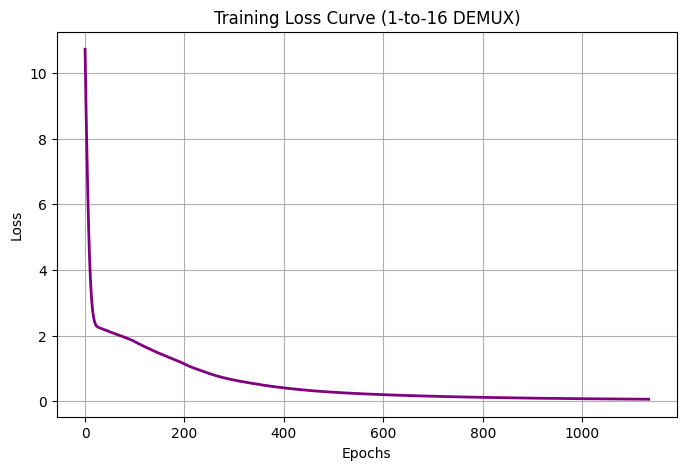

In [1]:
# demux_1to16_mlp.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ======================================================
# 1️⃣ Dataset creation for 1-to-16 DEMUX
# ======================================================
X = []
y = []

# Select lines: 4 bits (0–15)
for sel in range(16):
    sel_bits = [int(x) for x in format(sel, '04b')]
    for data in [0, 1]:  # Data input can be 0 or 1
        inputs = [data] + sel_bits
        output = [0] * 16
        if data == 1:
            output[sel] = 1
        X.append(inputs)
        y.append(output)

X = np.array(X)
y = np.array(y)

print(f"Dataset Shape: Inputs = {X.shape}, Outputs = {y.shape}")

# ======================================================
# 2️⃣ Train the MLP Model
# ======================================================
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation='tanh',
                    solver='adam', learning_rate_init=0.01,
                    max_iter=4000, random_state=42)

mlp.fit(X, y)

# ======================================================
# 3️⃣ Evaluate Model Performance
# ======================================================
y_pred = mlp.predict(X)
y_pred_binary = (y_pred > 0.5).astype(int)

accuracy = accuracy_score(y, y_pred_binary)

print("\n=== 1-to-16 DE-MULTIPLEXER using Multi-Layer Perceptron ===")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report (for all 16 outputs):\n", classification_report(y, y_pred_binary))
print("\nConfusion Matrix (Flattened):\n", confusion_matrix(y.flatten(), y_pred_binary.flatten()))

# ======================================================
# 4️⃣ Plot Training Loss Curve
# ======================================================
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, linewidth=2, color='purple')
plt.title("Training Loss Curve (1-to-16 DEMUX)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [3]:
import joblib
joblib.dump(mlp, "frontend/models/1to16_DEMUX_mlp.pkl")

['frontend/models/1to16_DEMUX_mlp.pkl']